In [10]:
# -*- coding: utf-8 -*-
import pickle
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import osmnx as ox

## data load

In [11]:
# ====== Input file paths ======
ORIG_HEX_PATH = "./new_hexagraph/jeju_hexa_for_use.shp"                  # Original hexagon grid
NEW_HEX_GPKG  = "./new_hexagraph/hexa_network_with_road.gpkg"            # Road-constrained hexagons in GPKG format
NEW_HEX_LAYER = "hex_on_road"
NEW_HEX_SHP   = "./new_hexagraph/hexa_network_with_road.shp"             # Fallback road-constrained hexagon shapefile
GRAPH_PKL     = "./new_hexagraph/hexa_network_with_road.gpickle"         # Road-derived hexagon network graph
ROAD_GRAPHML  = "./road_network/jeju_drive_filtered_int_code.graphml"    # Original road network


# ====== 1) Load input data ======
orig_hex = gpd.read_file(ORIG_HEX_PATH)

try:
    new_hex = gpd.read_file(NEW_HEX_GPKG, layer=NEW_HEX_LAYER)
except Exception as e:
    print(f"Failed to read GPKG layer. Falling back to SHP: {e}")
    new_hex = gpd.read_file(NEW_HEX_SHP)

with open(GRAPH_PKL, "rb") as f:
    H = pickle.load(f)

# Load the original road network as a background layer.
G = ox.load_graphml(ROAD_GRAPHML)
_, edges_rd = ox.graph_to_gdfs(G)


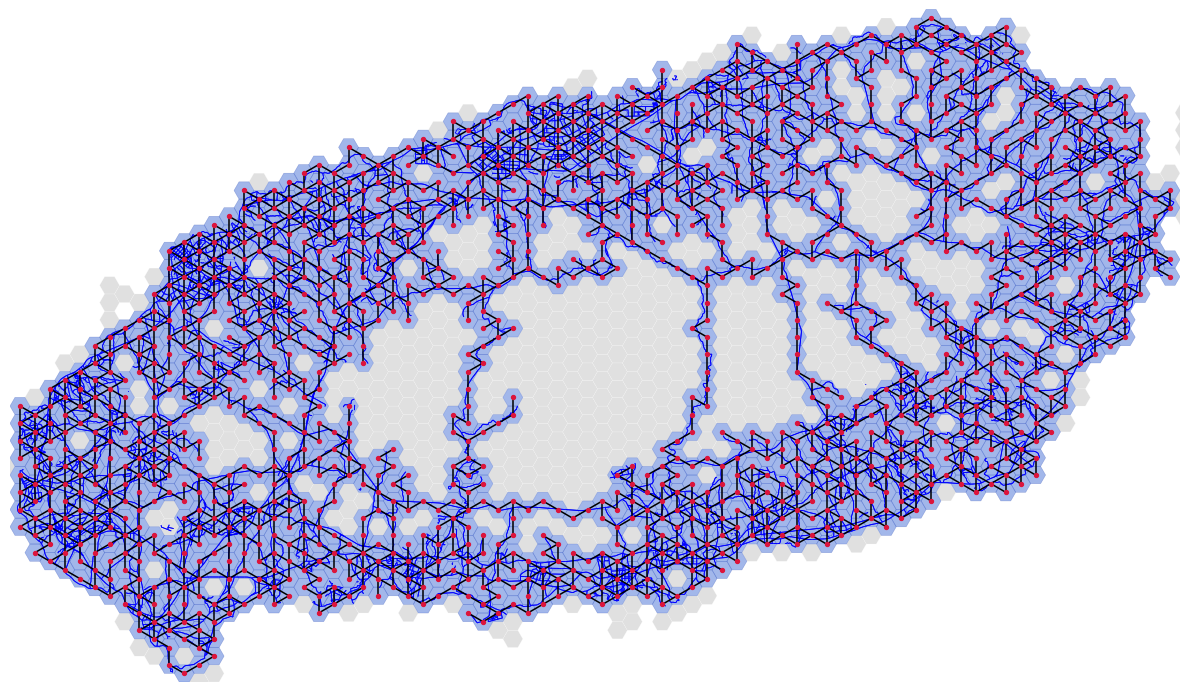

In [14]:
# CRS
if new_hex.crs != orig_hex.crs:
    new_hex = new_hex.to_crs(orig_hex.crs)
if edges_rd.crs != orig_hex.crs:
    edges_rd = edges_rd.to_crs(orig_hex.crs)

# Node/Edge GDF
new_hex_cent = new_hex.copy()
new_hex_cent["centroid"] = new_hex_cent.geometry.centroid

if "new_id" not in new_hex_cent.columns:
    raise ValueError("no 'id' column found")

new_hex_cent = new_hex_cent.set_index("new_id")

node_rows = []
for n, _d in H.nodes(data=True):
    if n not in new_hex_cent.index:
        continue
    c = new_hex_cent.loc[n, "centroid"]
    node_rows.append({"node_id": n, "geometry": Point(c.x, c.y)})
nodes_gdf = gpd.GeoDataFrame(node_rows, geometry="geometry", crs=orig_hex.crs)

edge_rows = []
node_geom = dict(zip(nodes_gdf["node_id"], nodes_gdf.geometry))
for u, v in H.edges():
    if u in node_geom and v in node_geom:
        edge_rows.append({"u": u, "v": v, "geometry": LineString([node_geom[u], node_geom[v]])})
edges_gdf = gpd.GeoDataFrame(edge_rows, geometry="geometry", crs=orig_hex.crs)

# Figure
fig, ax = plt.subplots(figsize=(12, 12))

if not new_hex.empty:
    xmin, ymin, xmax, ymax = new_hex.total_bounds
else:
    xmin, ymin, xmax, ymax = orig_hex.total_bounds

try:
    edges_rd_view = edges_rd.cx[xmin:xmax, ymin:ymax].copy()
except Exception:
    bbox_poly = gpd.GeoSeries([gpd.points_from_xy([xmin, xmax, xmax, xmin, xmin],
                                                  [ymin, ymin, ymax, ymax, ymin]).unary_union.envelope],
                              crs=new_hex.crs)
    edges_rd_view = edges_rd[edges_rd.intersects(bbox_poly.iloc[0])].copy()

# Background layers
orig_hex.plot(ax=ax, facecolor="lightgray", edgecolor="white", linewidth=0.2, alpha=0.7, zorder=1)

# New hexagons
new_hex.plot(ax=ax, facecolor="#2F6BFF", edgecolor="#1E40AF", linewidth=0.4, alpha=0.35, zorder=2)

# Roads
if not edges_rd_view.empty:
    edges_rd_view.plot(ax=ax, linewidth=0.6, color="blue", alpha=1, zorder=3)
else:
    edges_rd.plot(ax=ax, linewidth=0.6, color="#7f7f7f", alpha=1, zorder=3)

# Hexa network
if not edges_gdf.empty:
    edges_gdf.plot(ax=ax, linewidth=1.1, color="black", zorder=4)
if not nodes_gdf.empty:
    nodes_gdf.plot(ax=ax, markersize=8, color="crimson", zorder=5)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_axis_off()
plt.tight_layout()
plt.show()
